In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [27]:
data = pd.read_csv('../data/raw_dataset/train.csv')
data = data.drop(columns=['Id'])

**Let's explore our dataset**

In [28]:
data.shape #shape of the dataset, we have 1460 rows and 81 columns in the dataset.

(1460, 80)

In [29]:
data.head() #displaying the first 5 rows of the dataset.

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [30]:
data.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [34]:
data["PoolQC"].value_counts()

PoolQC
Gd    3
Ex    2
Fa    2
Name: count, dtype: int64

In [35]:
data["MSZoning"].value_counts().sort_values()

MSZoning
C (all)      10
RH           16
FV           65
RM          218
RL         1151
Name: count, dtype: int64

In [36]:
data["LotFrontage"].value_counts()

LotFrontage
60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
138.0      1
160.0      1
152.0      1
153.0      1
46.0       1
Name: count, Length: 110, dtype: int64

In [13]:
data[data.columns[3]].value_counts()

LotArea
7200     25
9600     24
6000     17
10800    14
9000     14
         ..
26142     1
9262      1
17217     1
13175     1
9717      1
Name: count, Length: 1073, dtype: int64

In [14]:
data[data.columns[4]].value_counts()

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

In [15]:
data[data.columns[5]].value_counts()

Alley
Grvl    50
Pave    41
Name: count, dtype: int64

In [18]:
data[data.columns[6]].value_counts()

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

In [19]:
data[data.columns[7]].value_counts()

LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

In [20]:
data[data.columns[8]].value_counts()

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

In [21]:
data.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [22]:
data[data.columns[9]].value_counts()

LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

In [23]:
data['LandSlope'].value_counts()

LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

In [29]:
data['RoofMatl'].value_counts()

RoofMatl
CompShg    1434
Tar&Grv      11
WdShngl       6
WdShake       5
Metal         1
Membran       1
Roll          1
ClyTile       1
Name: count, dtype: int64

In [30]:
data["1stFlrSF"].value_counts()

1stFlrSF
864     25
1040    16
912     14
848     12
894     12
        ..
1423     1
913      1
1578     1
2073     1
1256     1
Name: count, Length: 753, dtype: int64

**Let's check correlations**

In [8]:
residual = data["1stFlrSF"] + data["2ndFlrSF"] + data["LowQualFinSF"]
data["GrLivArea"].corr(residual)

np.float64(1.0)

In [9]:
residual.head()

0    1710
1    1262
2    1786
3    1717
4    2198
dtype: int64

In [10]:
data["GrLivArea"].head()

0    1710
1    1262
2    1786
3    1717
4    2198
Name: GrLivArea, dtype: int64

In [ ]:
data[["1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea"]].head()

In [ ]:
data["LowQualFinSF"].value_counts()

<Axes: title={'center': 'GrLivArea Distribution'}, ylabel='Density'>

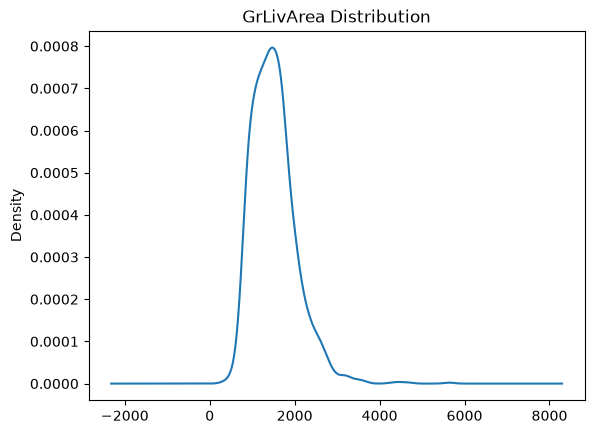

In [49]:
data["GrLivArea"].plot(kind='kde', title='GrLivArea Distribution')

In [42]:
test_1 = data[["1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea"]].corr()

In [43]:
test_1

,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea
1stFlrSF,1.000000,-0.202646,-0.014241,0.566024
2ndFlrSF,-0.202646,1.000000,0.063353,0.687501
LowQualFinSF,-0.014241,0.063353,1.000000,0.134683
GrLivArea,0.566024,0.687501,0.134683,1.000000


<Axes: >

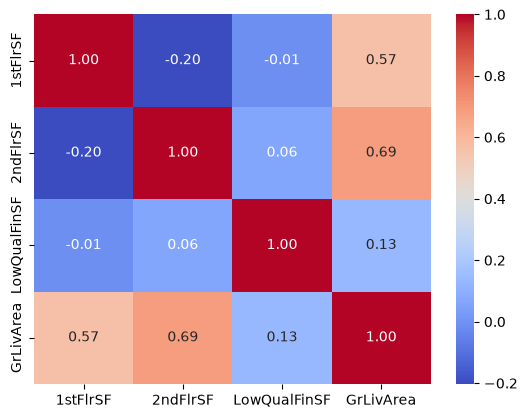

In [45]:
sns.heatmap(test_1, annot=True, cmap='coolwarm', fmt=".2f")

In [50]:
basement_testing = ["BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF"]

In [51]:
basement_corr = data[basement_testing].corr()

In [52]:
basement_corr

,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF
BsmtFinSF1,1.000000,-0.050117,-0.495251,0.522396
BsmtFinSF2,-0.050117,1.000000,-0.209294,0.104810
BsmtUnfSF,-0.495251,-0.209294,1.000000,0.415360
TotalBsmtSF,0.522396,0.104810,0.415360,1.000000


<Axes: title={'center': 'Basement Area Distribution'}, ylabel='Density'>

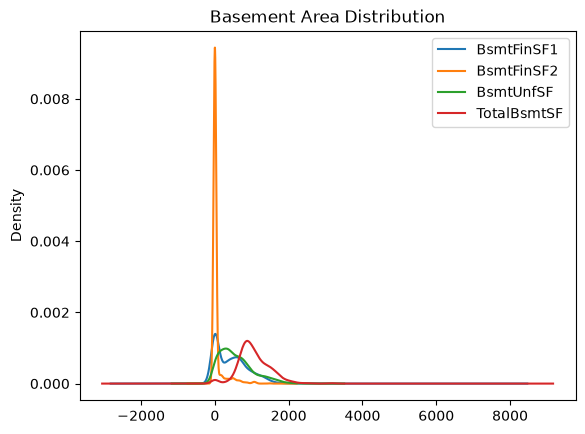

In [55]:
data[basement_testing].plot(kind='kde', title='Basement Area Distribution')

In [ ]:
to_be_dropped = ["1stFlrSF", "2ndFlrSF", "LowQualFinSF", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF"]

In [1]:
from assignments.helpers import preprocess_data

In [2]:
preprocessed_data = preprocess_data()

In [4]:
preprocessed_data.shape

(1460, 75)